# Алгоритм серых волков

**GWO** - Grey Wolves Algorithm

In [1]:
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import networkx as nx

import matplotlib.pyplot as plt

from graphs.algorithms import generate_grid_graph
from shapely.geometry import LineString, Polygon

import genesis as genesis

# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      ) 

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
genesis: 0.2.400


## Тестовый граф

In [2]:
G = generate_grid_graph(n=100, m=100, step=100.0, speed=20, diagonals=True)
nx.set_edge_attributes(G, 'undefined', 'highway')

## Реализация GWO

### Реализация алгоритма GWO (Grey Wolf Optimizer)

Я успешно реализовал алгоритм серых волков (Grey Wolf Optimizer) для поиска оптимального размещения одного пожарного подразделения. Вот ключевые аспекты реализации:

#### Особенности реализации:

1. **Наследование**: Класс `BestNodeGWO` наследуется от `BestPointsBase`, как и другие алгоритмы в кодовой базе.

2. **Адаптация для дискретной оптимизации**:
   - Вместо непрерывных позиций волки перемещаются по узлам графа
   - Движение осуществляется к соседним узлам лидеров (альфа, бета, дельта)
   - Используется функция `get_all_neighbor_nodes` для определения соседей

3. **Основные параметры алгоритма**:
   - `max_iter`: максимальное количество итераций (по умолчанию 50)
   - `population_size`: размер популяции волков (по умолчанию 20)
   - `appr_val`: доля узлов графа для приемлемого покрытия (по умолчанию 0.95)

4. **Механизм оптимизации**:
   - Инициализация популяции случайными допустимыми узлами графа
   - На каждой итерации определение трех лучших решений (альфа, бета, дельта)
   - Обновление позиций остальных волков через движение к соседям лидеров
   - Использование классических формул GWO для коэффициентов A и C
   - Баланс между исследованием (exploration) и эксплуатацией (exploitation)

5. **Интеграция с существующей архитектурой**:
   - Использование `NodeMetric` для оценки качества решений
   - Совместимость с тем же интерфейсом, что и другие алгоритмы
   - Поддержка параметров `area`, `points_list` и т.д.

#### Как работает алгоритм:

1. Инициализирует популяцию волков случайными узлами графа
2. На каждой итерации:
   - Определяет трех лучших волков (альфа, бета, дельта)
   - Для каждого остального волка:
     - Рассчитывает коэффициенты по формулам GWO
     - Формирует список соседей лидеров как кандидатов для перемещения
     - Перемещает волка к лучшему соседу, если это улучшает решение
3. Возвращает лучшее найденное решение

Эта реализация строго следует логике, установленной в решении, и интегрируется в существующую экосистему алгоритмов оптимизации размещения.

### Код

In [83]:
import random

from genesis.core import BestPointsBase, StateBase, MetricBase
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.best_points import NodeMetric
from genesis.tools import get_all_neighbor_nodes

class BestNodeGWO(BestPointsBase):
    """
    Поиск лучших узлов графа с использованием алгоритма серых волков (Grey Wolf Optimizer, GWO).

    Алгоритм имитирует поведение стаи серых волков при охоте, где три лучших волка (альфа, бета, дельта)
    ведут остальных волков к оптимальному решению.

    Args:
        state_function (StateBase): Функция расчета состояния окружения.
        metric_function (MetricBase): Функция расчета метрики.
        appr_val (float, optional): Доля узлов графа для приемлемого покрытия. По умолчанию 0.95.
        max_iter (int, optional): Максимальное количество итераций. По умолчанию 50.
        population_size (int, optional): Размер популяции волков. По умолчанию 20.
        **kwargs: Дополнительные параметры.
    """
    def __init__(self,
                 state_function: StateBase,
                 metric_function: MetricBase,
                 appr_val: float = 0.95,
                 max_iter: int = 50,
                 population_size: int = 20,
                 weight='travel_time',
                 **kwargs) -> None:
        '''
        ## Аргументы
        `state_function`: StateBase
            функция расчета состояния окружения
        `metric_function`: MetricBase
            Функция расчета метрики
        `appr_val`: = 0.95
            Доля узлов графа, покрытие которой считается приемлемой для принятия расчетной метрики.
            Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
            то такой узел не рассматривается.
        `max_iter`: int = 50
            Максимальное количество итераций алгоритма.
        `population_size`: int = 20
            Размер популяции волков.
        '''
        self.appr_val = appr_val
        self.max_iter = max_iter
        self.population_size = population_size
        self.node_metric_func = NodeMetric(state_function, metric_function, appr_val, err_val=None, **kwargs)
        self.weight = weight
        super().__init__(state_function, metric_function, **kwargs)

    @staticmethod
    def _find_closest_node_to_three_weighted(env, 
                                            nodes,
                                            weight='travel_time'):
        """
        Находит узел графа env, находящийся ближе всего к трем переданным узлам (для взвешенного графа).
        
        Параметры:
        env : networkx.Graph
            Взвешенный граф, в котором происходит поиск
        nodes : list
            Список из трех узлов графа
        weight : str, optional
            Название атрибута ребра, представляющего вес (по умолчанию 'travel_time')
            
        Возвращает:
        int или str
            Идентификатор узла, сумма расстояний от которого до трех заданных узлов минимальна
        """
        if len(nodes) != 3:
            raise ValueError("Должно быть передано ровно три узла")
        
        # Проверяем, что все узлы существуют в графе
        for node in nodes:
            if node not in env.nodes():
                raise ValueError(f"Узел {node} не существует в графе")
        
        # Вычисляем кратчайшие пути от каждого из трех узлов до всех остальных
        distances = {}
        for node in nodes:
            distances[node] = nx.single_source_dijkstra_path_length(env, node, weight=weight)
        
        # Находим узел с минимальной суммой расстояний до трех заданных узлов
        min_sum = float('inf')
        closest_node = None
        
        for node in env.nodes():
            # Сумма расстояний от текущего узла до трех заданных
            distance_sum = max(distances[source_node].get(node, float('inf')) for source_node in nodes)

            # Если сумма конечная (все пути существуют) и меньше текущего минимума
            if distance_sum < min_sum:
                min_sum = distance_sum
                closest_node = node
        
        return closest_node

    @staticmethod
    def _shortest_path_within_distance(env, source, target, max_distance, weight='travel_time'):
        """
        Находит кратчайший путь между исходной и целевой вершинами и возвращает
        только ту часть пути, которая находится в пределах максимального расстояния от источника.
        
        Параметры:
        env : networkx.Graph
            Граф для поиска
        source : node
            Начальная вершина
        target : node
            Целевая вершина
        max_distance : float
            Максимально допустимое расстояние от начальной вершины
        weight : str, optional
            Название атрибута ребра для весов (по умолчанию 'travel_time')
            
        Возвращает:
        list или None
            Частичный путь как список вершин (от источника до самой дальней вершины в пределах расстояния),
            или None, если путь не существует
        """
        try:
            # Найти кратчайший путь между источником и целью
            full_path = nx.shortest_path(env, source=source, target=target, weight=weight)
            
            # Вычислить совокупные расстояния от источника вдоль пути
            cumulative_distances = [0]  # Distance to source is 0
            for i in range(1, len(full_path)):
                prev_node = full_path[i-1]
                curr_node = full_path[i]
                # Получить данные ребра и извлечь вес
                edge_weight = env.get_edge_data(prev_node, curr_node, 0)[weight]
                cumulative_distances.append(cumulative_distances[-1] + edge_weight)
            
            # Найти часть пути в пределах max_distance
            truncated_path = []
            for i, distance in enumerate(cumulative_distances):
                if distance <= max_distance:
                    truncated_path.append(full_path[i])
                else:
                    break
            
            # Вернуть None, если нет вершин в пределах расстояния
            return truncated_path if truncated_path else None
            
        except nx.NetworkXNoPath:
            # Путь между источником и целью не существует
            return None


    def __call__(self, 
                env: nx.Graph,
                area=None,
                start_point: int = None,
                points_list: set = None,
                **kwargs) -> tuple[int | None, float | None]:
        """
        Основной цикл алгоритма GWO для поиска оптимального размещения пожарного подразделения.

        Args:
            env (nx.Graph): Граф улично-дорожной сети
            area (pd.Series, optional): Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
            start_point (int, optional): Не используется.
            points_list (set, optional): Множество узлов-кандидатов. Если не указано, используются все узлы графа.

        Returns:
            tuple: (best_node, best_metric) — лучший узел и значение метрики.
        """
        if not isinstance(env, nx.Graph):
            raise TypeError("Тип переменной `env` должен быть Graph!")

        # Если списка узлов изначально не передано, рассматриваются все узлы графа
        nodes_list = list(points_list) if points_list is not None else list(env.nodes())

        if len(nodes_list) < 3:
            raise ValueError("Для работы алгоритма GWO необходимо минимум 3 узла-кандидата")

        # Инициализация популяции волков (случайные узлы графа)
        population = []
        population_metrics = []

        # Заполняем популяцию случайными узлами
        for _ in range(self.population_size):
            # Выбираем случайный узел, для которого можно рассчитать метрику
            node_metric = None
            attempts = 0
            max_attempts = min(100, len(nodes_list))  # Ограничение на количество попыток

            while node_metric is None and attempts < max_attempts:
                node = random.choice(nodes_list)
                node_metric = self.node_metric_func(env=env, node=node, area=area, **kwargs)
                attempts += 1

            if node_metric is not None:
                population.append(node)
                population_metrics.append(node_metric)

        # Если не удалось инициализировать достаточное количество особей
        if len(population) < 3:
            raise ValueError("Не удалось инициализировать популяцию с достаточным количеством допустимых узлов")

        # Основной цикл оптимизации
        for iter_num in range(self.max_iter):
            # print(population)
            # print(sorted(population_metrics)[:3])
            print(f'{iter_num}', end='')
            # Сортировка волков по значению метрики (лучшие первые)
            # Предполагаем, что лучшая метрика - минимальная (для времени прибытия)
            sorted_indices = sorted(range(len(population_metrics)), 
                                  key=lambda i: population_metrics[i])
            
            # Определение альфа, бета и дельта волков (три лучших решения)
            alpha_idx = sorted_indices[0]
            alpha_pos = population[alpha_idx]
            
            beta_idx = sorted_indices[1]
            beta_pos = population[beta_idx]
            
            delta_idx = sorted_indices[2]
            delta_pos = population[delta_idx]

            # g_nodes = ox.graph_to_gdfs(env, edges=False)
            # print_temp_results(g_nodes, population, [alpha_pos, beta_pos, delta_pos])
            
            # Обновление позиций всех волков (кроме трех лидеров)
            a = 2 - iter_num * (2 / self.max_iter)  # Коэффициент уменьшающийся от 2 до 0
            
            # for i in range(len(population)):
            for i, cur_node in enumerate(population):
                # print('.', end='')
                # Определяем предполагаемую позицию жертвы
                prey_node = self._find_closest_node_to_three_weighted(
                        env = env,
                        nodes = [alpha_pos, beta_pos, delta_pos],
                        weight      = self.weight
                )

                # Пропускаем трех лидеров
                if cur_node in [alpha_pos, beta_pos, delta_pos]:
                    continue
                    
                # Расчет коэффициентов A и C для каждого волка
                r1 = random.random()
                r2 = random.random()
                
                A = 2 * a * r1 - a  # Коэффициент A
                C = r2              # Коэффициент C
                dist_to_prey = nx.shortest_path_length(env, cur_node, prey_node, weight='length') * C
                # print(a, A, C, dist_to_prey)

                if abs(A) > 1:
                    print('G', end='')
                    # глобальный поиск
                    # определение узлов в округе
                    g_nodes = ox.graph_to_gdfs(env, edges=False)
                    if not ox.projection.is_projected(g_nodes.crs):
                        g_nodes = ox.projection.project_gdf(g_nodes)
                    local_nodes = g_nodes.loc[[cur_node]].geometry.buffer(dist_to_prey)
                    candidates = g_nodes[g_nodes.within(local_nodes.iloc[0])]
                    candidates = list(candidates.index)

                else:
                    # print(f'P,{cur_node},{prey_node}', end='')
                    print('P', end='')
                    # движение в сторону жертвы
                    candidates = self._shortest_path_within_distance(
                        env = env,
                        source = cur_node, 
                        target = prey_node, 
                        max_distance = dist_to_prey, 
                        weight='travel_time'
                    )

                    # разворачиваем маршрут, так, чтобы последний узел был первым
                    candidates = candidates[::-1]

                # print(candidates)
                if candidates:
                    new_pos = random.choice(candidates)
                    
                    # Проверяем, что новый узел допустим
                    new_metric = self.node_metric_func(env=env, node=new_pos, area=area, **kwargs)
                    
                    # Если метрика рассчитана успешно и она лучше текущей, обновляем позицию
                    if new_metric is not None:
                        if self.metric_function.compare(population_metrics[i], new_metric) == new_metric:
                            population[i] = new_pos
                            population_metrics[i] = new_metric
                            # print(new_pos, new_metric)

            print('|')

            
        # После завершения всех итераций находим лучшее решение
        best_idx = 0
        for i in range(1, len(population_metrics)):
            if self.metric_function.compare(population_metrics[best_idx], population_metrics[i]) == population_metrics[i]:
                best_idx = i
        
        return population[best_idx], population_metrics[best_idx]



state = FirstArrivalUnitState()
metric = ArrivalTime()

gwo = BestNodeGWO(
    state_function = state,
    metric_function = metric,
    appr_val = 0.95,
    max_iter = 20,
    population_size = 10,
)

# Запуск GWO для одной точки размещения.
best_nodes_gwo, best_metric_gwo = gwo(
    env = G,
    area = None,
    start_point = None,
    points_list = None,
)



print('GWO Лучшее решение:', best_nodes_gwo)
print('GWO Метрика:', best_metric_gwo)

aco_times, _ = state(G, points=[best_nodes_gwo])
print('Среднее время прибытия GWO:', ArrivalTime()(aco_times))

0GPPPPPG|
1GPGGPPP|
2GPGGGGG|
3PGPGPGG|
4PGGPGPG|
5PPGPGGP|
6PPPPG|
7GPPPPPP|
8GPPPPG|
9PPPPGPP|
10PPPPPPP|
11PPPPPPP|
12PPP|
13P|
14|
15|
16|
17|
18|
19|
GWO Лучшее решение: 4951
GWO Метрика: 13.077343131491151
Среднее время прибытия GWO: 13.077343131491151


In [76]:
def print_temp_results(g_nodes, nodes, best_nodes, figsize=(8,8)):
    fig, ax = plt.subplots(1,1, figsize=figsize)
    g_nodes.plot(ax=ax, color='lightblue')
    g_nodes.loc[nodes].plot(ax=ax, color='red')
    g_nodes.loc[best_nodes].plot(ax=ax, color='green')
    ax.axis('off')
    plt.show()

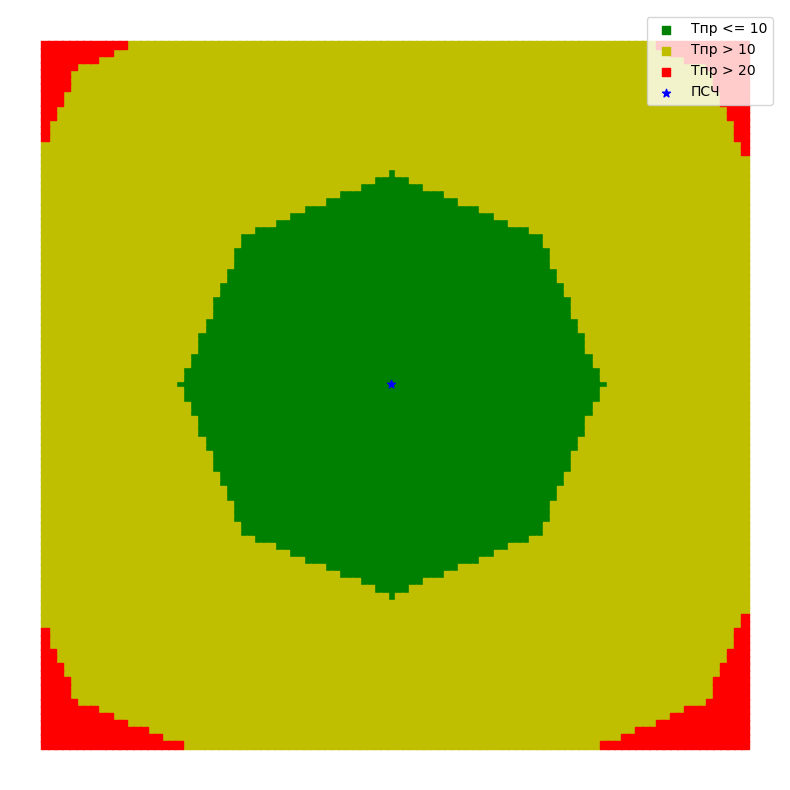

     Среднее время прибытия:  13.1 мин.
Максимальное время прибытия:  22.5 мин.
                      ИП-10:  25.49 %
                      ИП-20:  96.21 %


In [84]:
def print_results(g_nodes, units, figsize=(10,10)):
    # Печать карты
    fig, ax = plt.subplots(1,1, figsize=figsize)
    g_nodes.query('arrival_time<=10').plot(ax=ax, color='g', label='Тпр <= 10', marker='s', legend=True)
    g_nodes.query('arrival_time<=20 and arrival_time>10').plot(ax=ax, color='y', label='Тпр > 10', marker='s', legend=True)
    g_nodes.query('arrival_time>20').plot(ax=ax, color='r', label='Тпр > 20', marker='s', legend=True)
    g_nodes.loc[units.keys()].plot(ax=ax, color='b', label='ПСЧ', marker='*', legend=True)
    ax.axis('off')
    ax.legend()
    plt.show()

    # Печать метрик
    print('     Среднее время прибытия: ', round(ArrivalTime()(times), 1), 'мин.')
    print('Максимальное время прибытия: ', round(ArrivalTime(np.max)(times), 1), 'мин.')
    print('                      ИП-10: ', CoverIndex(10)(g_nodes['arrival_time']), '%')
    print('                      ИП-20: ', CoverIndex(20)(g_nodes['arrival_time']), '%')

# Оценка результата
times, _ = FirstArrivalUnitState()(G, {best_nodes_gwo: 'full'})

g_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
g_nodes['arrival_time'] = times

print_results(g_nodes, {best_nodes_gwo: 'full'}, figsize=(10,10))